In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

In [3]:
STUDY_DIR = Path("/Users/sean/code/study-hard/power-systems-ops/data/Multi-Stage_Aging_Study")

In [4]:
from power_systems_ops.battery.data_import import import_datafile
import power_systems_ops.battery.feature_extraction as ext

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import traceback

In [127]:
def infer_stage(file):
    if "Stage_1" in str(file):
        return 1
    elif "Stage_2" in str(file):
        return 2
    else:
        raise ValueError("No stage in path!")

In [56]:
class Checkup:
    def __init__(self, file):
        self.file = file
        self.infer_stage()
        self.parse_filename()
        self.experiment_id = "_".join([self.experiment, str(self.stage)])
        self.read_meta()
        self.read_sensor_file()
        self.experiment_start = None
        self._cum_fec = None

    def infer_stage(self):
        self.stage = infer_stage(self.file)

    def parse_filename(self):
        words = file.stem.split("_")
        self.experiment = "_".join(words[:3])
        self.number = int(words[3])
        self.type = "_".join(words[4:])

    def _meta_file(self):
        m = file.parent / (file.stem + "_meta.txt")
        if not m.exists():
            print(f"Warning: meta file {m.name} not found")
            return None
            # raise FileNotFoundError(f"Couldn't find: {m}")
        return m
        
    def read_meta(self):
        meta_file = self._meta_file()
        self.meta = {}
        if meta_file is None:
            # We'll just skip with a warning for now...
            return
        with open(meta_file, 'r') as f:
            for line in f:
                if line.startswith("--"):
                    # The rest of the file just depicts the schema of the associated sensor file.
                    break
                words = line.strip().split(": ")
                key = words[0]
                value = ": ".join(words[1:])
                self.meta[key] = value

    def read_sensor_file(self):
        try:
            # Oh, dang this is loading everything into memory... No wonder everything is so slow... Swap swap swap.
            self.df = import_datafile(self.file)
        except KeyError:
            self.df = None
            # This is the error thrown when there are no sensor readings...
            self.capacity = {}
            self.fec = 0
            raise  # We're just gonna skip these now...
        self.capacity = ext.capacity(self.df)
        # TODO: Correct for erroneous cycles here??
        self.fec = ext.fec_extract(self.df)

    @property
    def row(self):
        row = {
            attr: getattr(self, attr)
            for attr in ["experiment_id", "number", "type", "calendar_time", "cum_fec"]
        }
        row.update(self.meta)
        row.update(self.capacity)
        return row

    @property
    def measurement_start_time(self):
        try:
            return datetime.strptime(self.meta["Measurement start date"], "%d.%m.%Y")
        except ValueError:
            # For whatever reason, dates are recorded in different formats...
            return datetime.strptime(self.meta["Measurement start date"], "%d.%m.%y")

    @property
    def time(self):
        """Datetime at which the capacity was measured for checkups, or at which cycling start for cycling measurement."""
        if "t_charge" in self.capacity and not np.isnan(self.capacity["t_charge"]):
            run_time = self.capacity["t_charge"]
        else:
            # For cycling.
            run_time = self.df.iloc[0].run_time
        return self.measurement_start_time + timedelta(seconds=run_time)

    def set_experiment_start(self, start_date):
        self.experiment_start = start_date

    @property
    def calendar_time(self):
        """The number of days since the first capacity measurement was taken"""
        if self.experiment_start is None:
            raise ValueError("experiment_start must be set before calendar_time can be assessed.")
        return (self.time - self.experiment_start).days

    def set_cum_fec(self, cum_fec):
        self._cum_fec = cum_fec
        
    @property
    def cum_fec(self):
        if self._cum_fec is None:
            raise ValueError("Must set_cum_fec first.")
        return self._cum_fec
        
        


In [67]:
checkups = []
errors = []
for i, file in enumerate(STUDY_DIR.rglob("*.csv")):
    if i % 100 == 0:
        print(f"Parsing file {i}: {file.name}")
    if file.name == "experiments_meta.csv":
        # Everything else is a measurement file.
        continue
    try:
        checkups.append(Checkup(file))    
    except Exception as exc:
        print(f"Warning: exception {exc} loading {file.name}")
        traceback.print_exception(exc)
        errors.append((file, exc))

    # if i > 30:
    #     break

Parsing file 0: measurements.csv


Traceback (most recent call last):
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1233060445.py", line 10, in <module>
    checkups.append(Checkup(file))
                ^^^^^^^^^^^^^
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 4, in __init__
    self.infer_stage()
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 18, in infer_stage
    raise ValueError("No stage in path!")
ValueError: No stage in path!


Traceback (most recent call last):
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1233060445.py", line 10, in <module>
    checkups.append(Checkup(file))
                ^^^^^^^^^^^^^
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 8, in __init__
    self.read_sensor_file()
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 52, in read_sensor_file
    self.df = import_datafile(self.file)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sean/code/study-hard/power-systems-ops/src/power_systems_ops/battery/data_import.py", line 21, in import_datafile
    raise SensorDataNotFound()
power_systems_ops.battery.data_import.SensorDataNotFound


Traceback (most recent call last):
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1233060445.py", line 10, in <module>
    checkups.append(Checkup(file))
                ^^^^^^^^^^^^^
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 8, in __init__
    self.read_sensor_file()
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 52, in read_sensor_file
    self.df = import_datafile(self.file)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sean/code/study-hard/power-systems-ops/src/power_systems_ops/battery/data_import.py", line 21, in import_datafile
    raise SensorDataNotFound()
power_systems_ops.battery.data_import.SensorDataNotFound


Parsing file 100: TP_k05_03_01_ET_T23.csv
Parsing file 200: TP_z21_03_19_exCU.csv


...

Traceback (most recent call last):
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1233060445.py", line 10, in <module>
    checkups.append(Checkup(file))
                ^^^^^^^^^^^^^
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 8, in __init__
    self.read_sensor_file()
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 52, in read_sensor_file
    self.df = import_datafile(self.file)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sean/code/study-hard/power-systems-ops/src/power_systems_ops/battery/data_import.py", line 21, in import_datafile
    raise SensorDataNotFound()
power_systems_ops.battery.data_import.SensorDataNotFound


Parsing file 2200: TP_z01_01_04_ZYK.csv
Parsing file 2300: TP_z16_02_33_AT_T10.csv
Parsing file 2400: TP_z03_02_08_ZYK.csv


Traceback (most recent call last):
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1233060445.py", line 10, in <module>
    checkups.append(Checkup(file))
                ^^^^^^^^^^^^^
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 8, in __init__
    self.read_sensor_file()
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 52, in read_sensor_file
    self.df = import_datafile(self.file)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sean/code/study-hard/power-systems-ops/src/power_systems_ops/battery/data_import.py", line 21, in import_datafile
    raise SensorDataNotFound()
power_systems_ops.battery.data_import.SensorDataNotFound


Traceback (most recent call last):
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1233060445.py", line 10, in <module>
    checkups.append(Checkup(file))
                ^^^^^^^^^^^^^
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 8, in __init__
    self.read_sensor_file()
  File "/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_60048/1237243825.py", line 52, in read_sensor_file
    self.df = import_datafile(self.file)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sean/code/study-hard/power-systems-ops/src/power_systems_ops/battery/data_import.py", line 21, in import_datafile
    raise SensorDataNotFound()
power_systems_ops.battery.data_import.SensorDataNotFound


Parsing file 2500: TP_z09_02_22_ZYK.csv
Parsing file 2600: TP_z12_01_23_CU.csv
Parsing file 2700: TP_z21_01_30_ZYK.csv
Parsing file 2800: TP_z21_03_16_ZYK.csv
Parsing file 2900: TP_z21_01_01_ET_T45.csv
Parsing file 3000: TP_z06_02_03_CU.csv
Parsing file 3100: TP_z25_01_05_CU.csv
Parsing file 3200: TP_z12_02_16_ZYK.csv
Parsing file 3300: TP_z01_03_14_ZYK.csv
Parsing file 3400: TP_z17_01_05_CU.csv
Parsing file 3500: TP_k11_02_08_AT_T45.csv
Parsing file 3600: TP_k10_01_01_ET_T10.csv
Parsing file 3700: TP_z09_03_04_ZYK.csv
Parsing file 3800: TP_z01_01_22_ZYK.csv
Parsing file 3900: TP_z23_03_01_ET_T45.csv
Parsing file 4000: TP_z05_02_23_CU.csv
Parsing file 4100: TP_z23_02_20_ZYK.csv
Parsing file 4200: TP_z10_01_13_exCU.csv
Parsing file 4300: TP_k08_04_01_ET_T10.csv
Parsing file 4400: TP_z07_01_18_ZYK.csv
Parsing file 4500: TP_z22_03_06_ZYK.csv
Parsing file 4600: TP_z11_03_02_ZYK.csv
Parsing file 4700: TP_z03_01_33_AT_T10.csv
Parsing file 4800: TP_z21_02_08_ZYK.csv
Parsing file 4900: TP_z18_

In [86]:
# Backup before modifying checkups variable
# checkups_full = checkups

In [118]:
import itertools

In [122]:
from itertools import islice

def chunked(iterable, size):
    it = iter(iterable)
    while chunk := list(islice(it, size)):
        yield chunk

In [137]:
from power_systems_ops.battery.data_import import SensorDataNotFound

In [140]:
for file, exc in errors:
    if not isinstance(exc, SensorDataNotFound):
        print(file.name, exc)

measurements.csv No stage in path!


In [134]:
print(bold("Sensor Data Missing"))
print("-" * 100)
err_files = [f for f, _ in errors[1:]]
err_files.sort(key=lambda f: f.name)
for files in chunked(err_files, 3):
    print(" | ".join([f"Stage_{infer_stage(file)}/{file.name:20s}" for file in files]))

Sensor Data Missing
----------------------------------------------------------------------------------------------------
Stage_2/TP_z15_01_22_AT_T10.csv | Stage_2/TP_z15_01_22_AT_T45.csv | Stage_2/TP_z15_02_24_AT_T10.csv
Stage_2/TP_z15_02_24_AT_T45.csv | Stage_2/TP_z15_03_24_AT_T10.csv | Stage_2/TP_z15_03_24_AT_T45.csv
Stage_2/TP_z17_01_24_AT_T10.csv | Stage_2/TP_z17_01_24_AT_T45.csv | Stage_2/TP_z17_02_24_AT_T10.csv
Stage_2/TP_z17_02_24_AT_T45.csv | Stage_2/TP_z17_03_24_AT_T10.csv | Stage_2/TP_z17_03_24_AT_T45.csv
Stage_2/TP_z20_01_14_AT_T10.csv | Stage_2/TP_z20_01_14_AT_T45.csv | Stage_2/TP_z20_02_08_AT_T10.csv
Stage_2/TP_z20_02_08_AT_T45.csv | Stage_2/TP_z20_03_14_AT_T10.csv | Stage_2/TP_z20_03_14_AT_T45.csv
Stage_2/TP_z23_01_08_AT_T10.csv | Stage_2/TP_z23_01_08_AT_T45.csv | Stage_2/TP_z23_02_10_AT_T10.csv
Stage_2/TP_z23_02_10_AT_T45.csv | Stage_2/TP_z23_03_14_AT_T10.csv | Stage_2/TP_z23_03_14_AT_T45.csv


In [87]:
checkups_okay = []
time_errors = []
for c in checkups:
    try:
        c.time
        checkups_okay.append(c)
    except Exception:
        time_errors.append(c)

In [106]:
def bold(text):
    return f"\033[1m{text}\033[0m"

In [116]:
print(bold("Improperly Formatted Dates"))
print("-" * 50)
title = "filename"
print(f"{title:22s}| Measurement start date")
print("-" * 50)
for c in time_errors:
    print(f"{c.file.name:22s}| {c.meta.get("Measurement start date")}")


Improperly Formatted Dates
--------------------------------------------------
filename              | Measurement start date
--------------------------------------------------
TP_z01_02_20_ZYK.csv  | 13.17.2023
TP_z01_02_06_ZYK.csv  | 29.02.2023
TP_z02_02_06_ZYK.csv  | 29.02.2023
TP_z02_02_09_CU.csv   | None
TP_z19_01_31_CU.csv   | 22.10.222.12.233
TP_z03_01_06_ZYK.csv  | 29.02.2023
TP_z03_03_06_ZYK.csv  | 29.02.2023
TP_z01_01_06_ZYK.csv  | 29.02.2023
TP_z02_01_06_ZYK.csv  | 29.02.2023
TP_z03_02_06_ZYK.csv  | 29.02.2023
TP_z02_03_06_ZYK.csv  | 29.02.2023
TP_z01_03_20_ZYK.csv  | 13.17.2023
TP_z01_03_06_ZYK.csv  | 29.02.2023
TP_z12_03_07_exCU.csv | xx.12.2021


In [91]:
# Remove time errors
checkups = checkups_okay

In [92]:
groups = {}
for checkup in checkups:
    exp_id = checkup.experiment_id
    if exp_id not in groups:
        groups[exp_id] = [checkup]
    else:
        groups[exp_id].append(checkup)

In [93]:
for checkup_group in groups.values():
    checkup_group.sort(key=lambda c: c.time)

In [94]:
# set fec
# set experiment start
for checkout_group in groups.values():
    fec = [checkout.fec for checkout in checkout_group]
    cum_fec = np.cumsum(fec)
    for n, checkout in zip(cum_fec, checkout_group):
        checkout.set_experiment_start(checkout_group[0].time)
        checkout.set_cum_fec(n)


In [95]:
import pandas as pd

In [96]:
def save(checkups):
    df = pd.DataFrame([checkup.row for checkup in checkups])
    df = df.sort_values(by=['experiment_id', "number"]).reset_index(drop=True)
    df.to_csv(STUDY_DIR / "measurements.csv")

In [97]:
save(checkups)

In [64]:
for exp_id, cs in groups.items():
    print(len(cs), exp_id[3])
    if len(cs) > 5 and exp_id[3] == 'z':
        checkup_group = cs
        break

13 k
6 k
11 z


In [65]:
diffs = np.diff([c.time for c in checkup_group])

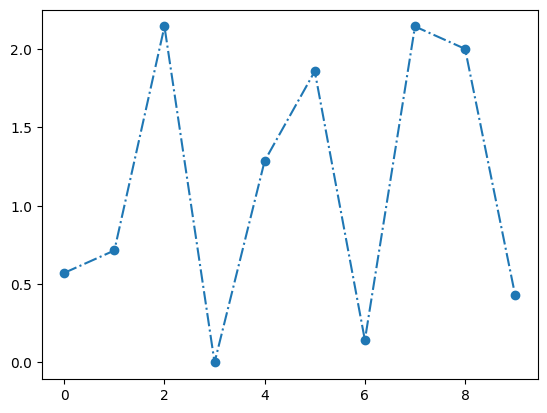

In [66]:
plt.plot([d.days / 7 for d in diffs], '-.o')


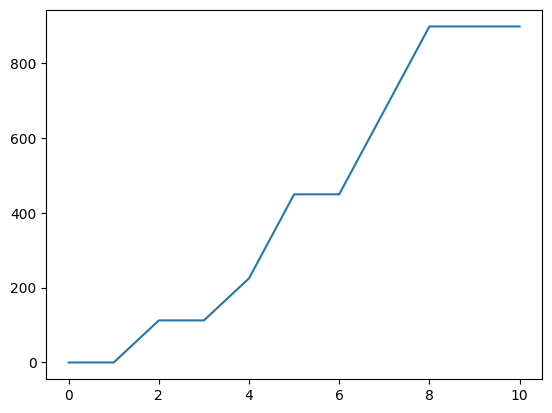

In [45]:
plt.plot([c.cum_fec for c in checkup_group])

(array([4., 0., 0., 0., 1., 1., 1., 2., 2., 1.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

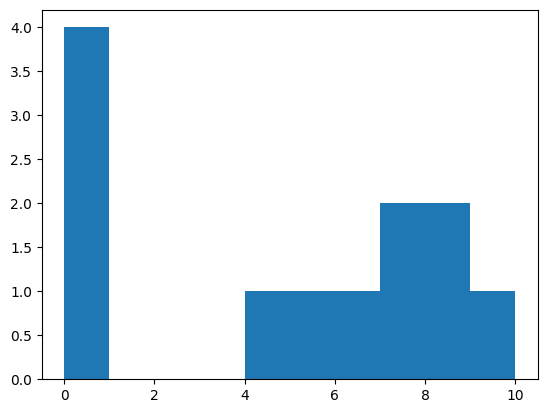

In [109]:
plt.hist([d.days / 7 for d in diffs], bins=np.linspace(0, 10, 11))

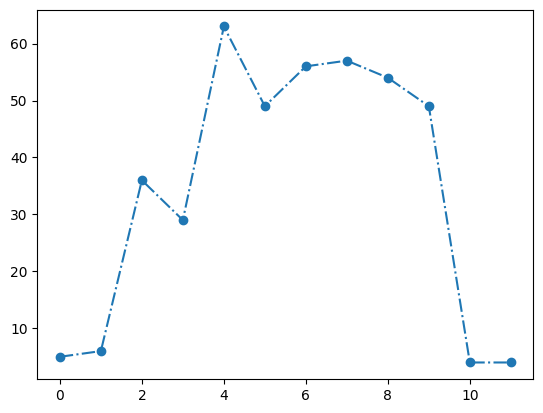

In [78]:
plt.plot(np.diff([t.days for t in true_time]), "-.o")

In [45]:
len(checkups)

5774

In [75]:
df

,experiment_id,number,type,Laboratory identifier,Internal cell serial,Testpoint,Measurement start date,Measurement device used,Test channel,Climate chamber used,Climate chamber temperature setpoint,Position within climate chamber,Q_mean
0,TP_k01_01_1,1,ET_T45,SIE,S001,k01,11.09.2021,BaSyTec X50.X.13.13.0864,CH01,CTS C-70/200 SN: 092061,45°C,left (Position 1 of 6),4.992518
1,TP_k01_01_1,1,ET_T23,SIE,S001,k01,15.09.2021,BaSyTec X50.X.13.13.0864,CH01,CTS C-70/200 SN: 092061,23°C,left (Position 1 of 6),4.903352
2,TP_k01_01_1,1,ET_T10,SIE,S001,k01,08.09.2021,BaSyTec X50.X.13.13.0864,CH01,CTS C-70/200 SN: 092061,10°C,left (Position 1 of 6),4.824177
3,TP_k01_01_1,2,CU,SIE,S001,k01,26.10.2021,BaSyTec X50.X.13.13.0864,CH01,CTS C-70/200 SN: 092061,23°C,left (Position 1 of 6),4.937685
4,TP_k01_01_1,3,exCU,SIE,S001,k01,30.11.2021,BaSyTec X50.X.13.13.0864,CH01,CTS C-70/200 SN: 092061,23°C,left (Position 1 of 6),4.916338
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5769,TP_z25_03_1,29,CU,HM,HM060,z25,11.08.22,"BaSyTec, SN:1937.0",CH28/CH29,ATT DY200T,23.0°C,top front mittig,4.230725
5770,TP_z25_03_1,30,ZYK,HM,HM060,z25,12.08.22,"BaSyTec, SN:1937.0",CH28/CH29,ATT DY200T,45.0°C,top front mittig,NaN
5771,TP_z25_03_1,31,AT_T23,HM,HM060,z25,12.09.2022,"BaSyTec, SN:1937",CH28/CH29,ATT DY200T,23°C,top front mittig,4.183451
5772,TP_z25_03_1,31,AT_T45,HM,HM060,z25,12.09.2022,"BaSyTec, SN:1937",CH28/CH29,ATT DY200T,45°C,top front mittig,4.280103


In [77]:
experiments = pd.read_csv(STUDY_DIR / "experiments_meta.csv")

In [84]:
experiments['stage'].astype(str)

0      1
1      1
2      1
3      1
4      1
      ..
274    2
275    2
276    2
277    2
278    2
Name: stage, Length: 279, dtype: object

In [87]:
experiments['id'] = experiments['serial'] + "_" + experiments['stage'].astype(str)

In [88]:
experiments.to_csv(STUDY_DIR / "experiments_meta_new.csv")

In [67]:
help(df.sort_values)

Help on method sort_values in module pandas.core.frame:

sort_values(by: 'IndexLabel', *, axis: 'Axis' = 0, ascending: 'bool | list[bool] | tuple[bool, ...]' = True, inplace: 'bool' = False, kind: 'SortKind' = 'quicksort', na_position: 'str' = 'last', ignore_index: 'bool' = False, key: 'ValueKeyFunc | None' = None) -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Sort by the values along either axis.

    Parameters
    ----------
    by : str or list of str
        Name or list of names to sort by.

        - if `axis` is 0 or `'index'` then `by` may contain index
          levels and/or column labels.
        - if `axis` is 1 or `'columns'` then `by` may contain column
          levels and/or index labels.
    axis : "{0 or 'index', 1 or 'columns'}", default 0
         Axis to be sorted.
    ascending : bool or list of bool, default True
         Sort ascending vs. descending. Specify list for multiple sort
         orders.  If this is a list of bools, must ma

In [36]:
import traceback

In [37]:
Checkup(errors[0][0])

KeyError: 0

In [42]:
errors[0][1]

TypeError('sequence item 1: expected str instance, int found')

In [23]:
checkups[0].meta

{'Laboratory identifier': ' SIE',
 'Internal cell serial': ' 167',
 'Testpoint': ' k01',
 'Measurement start date': ' 21.02.2023',
 'Measurement device used': ' BaSyTec X50.X.13.13.0864',
 'Test channel': ' CH02',
 'Climate chamber used': ' KB53 #03-50970',
 'Climate chamber temperature setpoint': ' 23°C',
 'Position within climate chamber': ' middle left (Position 2 of 6)'}

In [5]:
help(STUDY_DIR.glob)

Help on method glob in module pathlib:

glob(pattern, *, case_sensitive=None) method of pathlib.PosixPath instance
    Iterate over this subtree and yield all existing files (of any
    kind, including directories) matching the given relative pattern.

